In [43]:
## Configuración

# En esta sección se importan las librerías necesarias y se configura la conexión a la base de datos MariaDB para cargar la información en DataFrames de pandas.

In [44]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine


load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

In [45]:
## Crear conexión con MariaDB

# Se crea una conexión utilizando SQLAlchemy para facilitar la carga de información hacia DataFrames de pandas.

In [46]:
connection_string = (
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(connection_string)

In [47]:
## Verificar la conexión

# Se realiza una consulta sencilla para comprobar que la conexión a la base de datos fue establecida correctamente.

In [48]:
pd.read_sql("SELECT DATABASE() AS database_name;", engine)

,database_name
0,ag_db


In [49]:
# Carga de datos

# Se cargan las tablas de la base de datos en DataFrames de pandas para realizar el análisis solicitado.

In [50]:
companies_df = pd.read_sql("SELECT * FROM companies;", engine).rename(
    columns={
        "id": "company_id",
        "name": "company_name",
    }
)

programs_df = pd.read_sql("SELECT * FROM programs;", engine).rename(
    columns={
        "id": "program_id",
        "name": "program_name",
    }
)

statuses_df = pd.read_sql("SELECT * FROM statuses;", engine).rename(
    columns={
        "id": "status_id",
        "code": "status_code",
        "name": "sta#tus_name",
        "description": "status_description",
    }
)

students_df = pd.read_sql("SELECT * FROM students;", engine).rename(
    columns={
        "id": "student_id",
        "created_at": "student_created_at",
        "updated_at": "student_updated_at",
    }
)

enrollments_df = pd.read_sql("SELECT * FROM enrollments;", engine).rename(
    columns={
        "id": "enrollment_id",
        "created_at": "enrollment_created_at",
        "updated_at": "enrollment_updated_at",
    }
)

status_history_df = pd.read_sql("SELECT * FROM status_history;", engine).rename(
    columns={
        "id": "history_id",
    }
)

In [51]:
## Verificación de datos

# Se muestran las primeras filas de cada DataFrame para verificar que la información fue cargada correctamente.

In [52]:
display(companies_df.head())
display(programs_df.head())
display(statuses_df.head())
display(students_df.head())
display(enrollments_df.head())
display(status_history_df.head())

,company_id,company_name,created_at,updated_at
0,1,Alpura,2026-06-27 23:19:53,2026-06-27 23:19:53
1,2,Bayer,2026-06-27 23:19:53,2026-06-27 23:19:53
2,3,Coppel,2026-06-27 23:19:53,2026-06-27 23:19:53
3,4,Soriana,2026-06-27 23:19:53,2026-06-27 23:19:53


,program_id,program_name,created_at,updated_at
0,1,Lic. Administración,2026-06-27 23:19:53,2026-06-27 23:19:53
1,2,Lic. Contaduría,2026-06-27 23:19:53,2026-06-27 23:19:53
2,3,Lic. Logística,2026-06-27 23:19:53,2026-06-27 23:19:53
3,4,Lic. Negocios,2026-06-27 23:19:53,2026-06-27 23:19:53
4,5,Maestría en Dirección,2026-06-27 23:19:53,2026-06-27 23:19:53


,status_id,status_code,sta#tus_name,status_description
0,1,ENROLLED,Inscrito,Student enrollment has been registered.
1,2,ACTIVE,Activo,Student is currently active.
2,3,SUSPENDED,Suspendido,Student is temporarily suspended.
3,4,COMPANY_LEAVE,Baja empresa,Student left due to company-related reasons.
4,5,PROGRAM_LEAVE,Baja programa,Student voluntarily left the academic program.


,student_id,first_name,last_name,company_id,student_created_at,student_updated_at
0,1001,Luis,Cruz,4,2026-06-27 23:19:53,2026-06-27 23:19:53
1,1002,Andrés,Ramírez,3,2026-06-27 23:19:53,2026-06-27 23:19:53
2,1003,Daniela,Ortiz,4,2026-06-27 23:19:53,2026-06-27 23:19:53
3,1004,Luis,Reyes,4,2026-06-27 23:19:53,2026-06-27 23:19:53
4,1005,Sofía,Hernández,4,2026-06-27 23:19:53,2026-06-27 23:19:53


,enrollment_id,student_id,program_id,status_id,enrollment_date,enrollment_created_at,enrollment_updated_at
0,1,1001,4,2,2025-02-26,2026-06-27 23:19:53,2026-06-27 23:19:53
1,2,1002,2,3,2022-10-04,2026-06-27 23:19:53,2026-06-27 23:19:53
2,3,1003,3,7,2017-10-02,2026-06-27 23:19:53,2026-06-27 23:19:53
3,4,1004,3,7,2015-06-06,2026-06-27 23:19:53,2026-06-27 23:19:53
4,5,1005,3,5,2017-03-31,2026-06-27 23:19:53,2026-06-27 23:19:53


,history_id,enrollment_id,previous_status_id,new_status_id,changed_at,reason
0,1,1,1,2,2025-03-01 09:00:00,Completed onboarding process.
1,2,2,1,2,2022-10-10 08:30:00,Started academic activities.
2,3,2,2,3,2026-06-07 23:19:53,Pending required documentation.
3,4,3,1,2,2017-10-09 09:00:00,Started academic activities.
4,5,3,2,7,2021-07-15 12:00:00,Successfully completed the program.


In [53]:
## Construcción del DataFrame principal

# Se combinan las tablas principales para facilitar los análisis posteriores.

In [54]:
main_df = (
    enrollments_df
    .merge(students_df, on="student_id")
    .merge(companies_df, on="company_id")
    .merge(programs_df, on="program_id")
    .merge(statuses_df, on="status_id")
)

In [55]:
## Vista previa del DataFrame principal

# Se verifica el resultado de la integración de las tablas.

In [56]:
main_df[
    [
        "student_id",
        "first_name",
        "last_name",
        "company_name",
        "program_name",
        "status_code",
        "enrollment_date",
    ]
].head()

,student_id,first_name,last_name,company_name,program_name,status_code,enrollment_date
0,1001,Luis,Cruz,Soriana,Lic. Negocios,ACTIVE,2025-02-26
1,1002,Andrés,Ramírez,Coppel,Lic. Contaduría,SUSPENDED,2022-10-04
2,1003,Daniela,Ortiz,Soriana,Lic. Logística,GRADUATED,2017-10-02
3,1004,Luis,Reyes,Soriana,Lic. Logística,GRADUATED,2015-06-06
4,1005,Sofía,Hernández,Soriana,Lic. Logística,PROGRAM_LEAVE,2017-03-31


In [57]:
# Análisis 1 - Distribución de estatus por programa

# Se calcula la distribución del estatus actual de los estudiantes para cada programa académico utilizando una tabla pivote.

In [58]:
status_distribution = pd.pivot_table(
    main_df,
    index="program_name",
    columns="status_code",
    values="student_id",
    aggfunc="count",
    fill_value=0
)

status_distribution

status_code,ACTIVE,COMPANY_LEAVE,GRADUATED,PROGRAM_LEAVE,SUSPENDED
program_name,,,,,
Lic. Administración,0,1,0,0,0
Lic. Contaduría,0,0,0,0,2
Lic. Logística,0,0,7,2,0
Lic. Negocios,1,3,0,1,0
Maestría en Dirección,0,0,0,1,0
Maestría en Educación,0,0,0,0,1
Secundaria Abierta,0,0,0,1,0


In [59]:
# Análisis 2 - Evolución mensual de altas y bajas

# Se analiza la cantidad de estudiantes que ingresaron al estado activo y aquellos que causaron baja en cada mes, utilizando el historial de cambios de estatus.

In [62]:
history_analysis_df = (
    status_history_df
    .merge(
        statuses_df[["status_id", "status_code"]],
        left_on="new_status_id",
        right_on="status_id",
        how="left"
    )
)

history_analysis_df["month"] = (
    pd.to_datetime(history_analysis_df["changed_at"])
    .dt.to_period("M")
    .astype(str)
)

monthly_status_changes = (
    history_analysis_df
    .groupby(["month", "status_code"])
    .size()
    .unstack(fill_value=0)
)

monthly_trend = pd.DataFrame(index=monthly_status_changes.index)

monthly_trend["new_active"] = (
    monthly_status_changes.get("ACTIVE", 0)
)

monthly_trend["dropouts"] = (
    monthly_status_changes.get("COMPANY_LEAVE", 0)
    + monthly_status_changes.get("PROGRAM_LEAVE", 0)
)

monthly_trend

,new_active,dropouts
month,,
2015-04,1,0
2015-06,1,0
2015-07,1,0
2016-09,1,0
2017-04,1,0
2017-06,1,0
2017-10,2,0
2018-01,1,0
2018-02,0,1


In [ ]:
## Análisis 3. Tasa de estudiantes activos por programa

# Este análisis calcula el porcentaje de estudiantes con estatus **ACTIVE** respecto al total de inscritos en cada programa académico.

In [64]:
program_activity = (
    main_df
    .groupby("program_name")
    .agg(
        total_students=("student_id", "count"),
        active_students=("status_code", lambda x: (x == "ACTIVE").sum())
    )
)

program_activity["active_rate"] = (
    program_activity["active_students"]
    / program_activity["total_students"]
    * 100
).round(2)

program_activity.sort_values("active_rate", ascending=False)

,total_students,active_students,active_rate
program_name,,,
Lic. Negocios,5,1,20.0
Lic. Contaduría,2,0,0.0
Lic. Administración,1,0,0.0
Lic. Logística,9,0,0.0
Maestría en Dirección,1,0,0.0
Maestría en Educación,1,0,0.0
Secundaria Abierta,1,0,0.0


In [ ]:
## Análisis 4. Motivo de baja más frecuente

# Se analizan únicamente los registros cuyo nuevo estatus corresponde a una baja por empresa o baja de programa para identificar cuál es el motivo de baja más frecuente registrado en el historial.

In [65]:
dropout_reasons = (
    status_history_df
    .merge(
        statuses_df[["status_id", "status_code"]],
        left_on="new_status_id",
        right_on="status_id",
        how="left"
    )
    .query("status_code in ['COMPANY_LEAVE', 'PROGRAM_LEAVE']")
    .groupby("reason")
    .size()
    .reset_index(name="total")
    .sort_values("total", ascending=False)
)

dropout_reasons

,reason,total
0,Company no longer sponsors the program.,1
1,Company restructuring.,1
2,Employment contract ended.,1
3,Employment relationship ended.,1
4,Low academic attendance.,1
5,Personal reasons.,1
6,Student decided to leave the program.,1
7,Student requested withdrawal.,1
8,Voluntary withdrawal from the program.,1


In [ ]:
## Visualización 1. Distribución de estatus por programa

# Se genera una gráfica de barras apiladas para visualizar la distribución de estatus de los estudiantes en cada programa académico, permitiendo comparar la composición de estados entre programas.

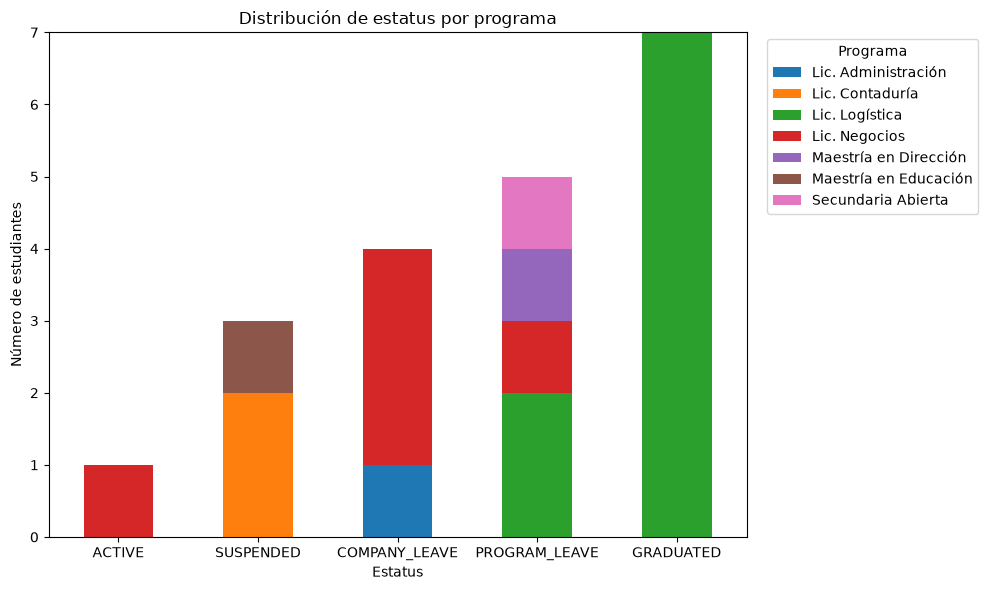

In [71]:
import matplotlib.pyplot as plt

status_distribution.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribución de estatus por programa")
plt.xlabel("Estatus")
plt.ylabel("Número de estudiantes")
plt.xticks(rotation=0)
plt.legend(title="Programa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [ ]:
## Visualización 2. Evolución mensual de altas y bajas

# Se presenta una gráfica de líneas que compara la cantidad de estudiantes que pasaron a estado activo contra aquellos que causaron baja por empresa o por programa en cada mes.

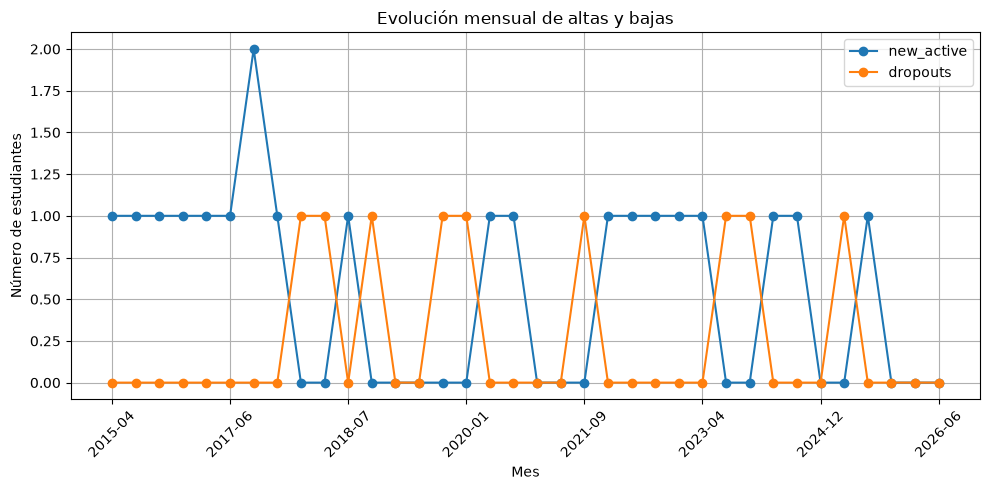

In [73]:
import matplotlib.pyplot as plt

monthly_trend.plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Evolución mensual de altas y bajas")
plt.xlabel("Mes")
plt.ylabel("Número de estudiantes")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()